# Unsupervised Learning — Discovering Cultural Patterns from Museum Metadata
Applies clustering and dimensionality reduction to the Met Museum's preprocessed feature matrix to discover latent groupings and evaluate alignment with curatorial departments and art historical periods.

In [25]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT    = os.path.abspath(os.path.join(os.getcwd(), '..'))
FIGURES = os.path.join(ROOT, 'outputs', 'figures')
os.makedirs(FIGURES, exist_ok=True)

### Load Preprocessed Data

In [2]:
import numpy as np
import joblib
from scipy.sparse import load_npz

X_train = load_npz('../data/processed/X_train.npz')
X_test  = load_npz('../data/processed/X_test.npz')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

le = joblib.load('../models/label_encoder.joblib')
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Departments: {le.classes_.tolist()}")

X_train: (387964, 214)
X_test:  (96992, 214)
Departments: ['Ancient Near Eastern Art', 'Arms and Armor', 'Arts of Africa, Oceania, and the Americas', 'Asian Art', 'Costume Institute', 'Drawings and Prints', 'Egyptian Art', 'European Paintings', 'European Sculpture and Decorative Arts', 'Greek and Roman Art', 'Islamic Art', 'Medieval Art', 'Modern and Contemporary Art', 'Musical Instruments', 'Photographs', 'Robert Lehman Collection', 'The American Wing', 'The Cloisters', 'The Libraries']


### Phase 1 - Exploring the Feature Space

Before clustering, we need to address two things: 
1) The features are on completely different scales — frequency-encoded columns like Culture are in the tens of thousands while TF-IDF and boolean columns sit between 0 and 1. Any distance-based algorithm will just measure Culture and Nationality differences unless we standardize. 
2) Most of the feature matrix is sparse TF-IDF values, so we should check how much of the variance is concentrated in a smaller number of directions and reduce accordingly.

### Standardization

In [5]:
from sklearn.preprocessing import StandardScaler

X_train_dense = X_train.toarray()
X_test_dense  = X_test.toarray()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dense)
X_test_scaled  = scaler.transform(X_test_dense)

print(f"Shape: {X_train_scaled.shape}")
print(f"Mean of first 5 cols: {X_train_scaled[:, :5].mean(axis=0).round(4)}")
print(f"Standard deviation of first 5 cols: {X_train_scaled[:, :5].std(axis=0).round(4)}")

Shape: (387964, 214)
Mean of first 5 cols: [ 0.  0.  0. -0. -0.]
Standard deviation of first 5 cols: [1. 1. 1. 1. 1.]


### TruncatedSVD: How Much Signal Is There?

We use TruncatedSVD rather than PCA because PCA centers the data and would destroy the sparsity structure of the TF-IDF columns. We fit 100 components and look at the cumulative variance curve to see where the useful signal tapers off.

In [6]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

svd = TruncatedSVD(n_components=100, random_state=42)
X_train_svd = svd.fit_transform(X_train_scaled)

cumulative_var = np.cumsum(svd.explained_variance_ratio_)

for n in [10, 25, 50, 75, 100]:
    print(f"{n:>3} components → {cumulative_var[n-1]:.3f} variance explained")

 10 components → 0.238 variance explained
 25 components → 0.414 variance explained
 50 components → 0.589 variance explained
 75 components → 0.711 variance explained
100 components → 0.817 variance explained


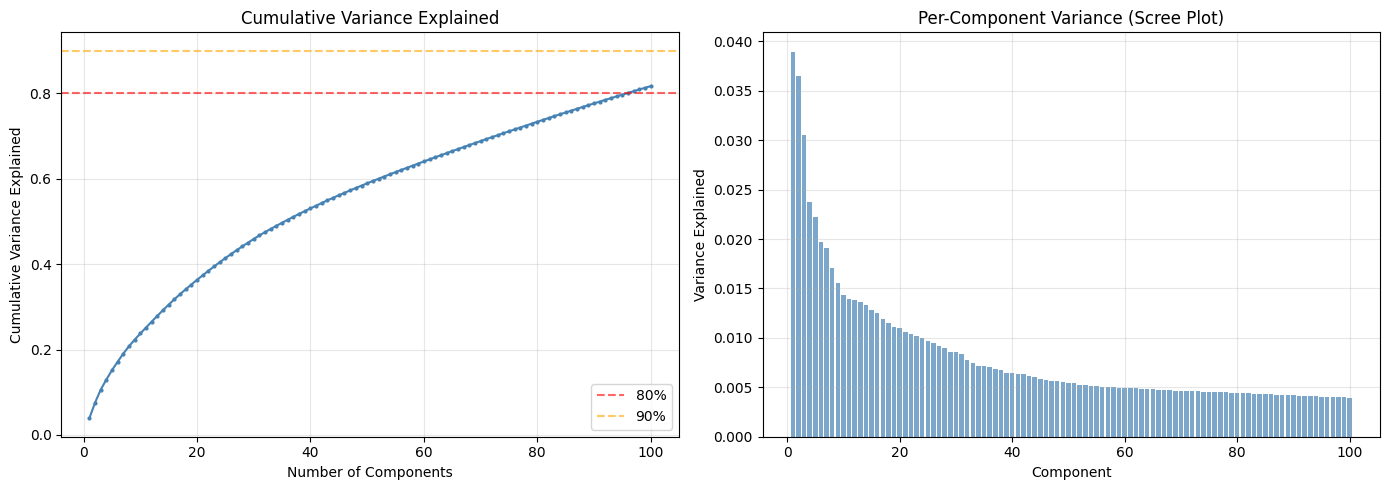

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 101), cumulative_var, marker='.', markersize=4, color='steelblue')
axes[0].axhline(y=0.80, color='red', linestyle='--', alpha=0.6, label='80%')
axes[0].axhline(y=0.90, color='orange', linestyle='--', alpha=0.6, label='90%')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Variance Explained')
axes[0].set_title('Cumulative Variance Explained')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(1, 101), svd.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Variance Explained')
axes[1].set_title('Per-Component Variance (Scree Plot)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'svd_variance_explained.png'), dpi=150, bbox_inches='tight')
plt.show()

### Choosing the Number of Components

In [11]:
for threshold in [0.50, 0.60, 0.70, 0.75, 0.80]:
    n = np.argmax(cumulative_var >= threshold) + 1
    print(f"{threshold:.0%} variance → {n} components")

print(f"\nMax variance with 100 components: {cumulative_var[-1]:.3f}")

50% variance → 36 components
60% variance → 52 components
70% variance → 73 components
75% variance → 84 components
80% variance → 96 components

Max variance with 100 components: 0.817


### Reduce to Final Dimensionality

50 components retains about approx 59% of the total variance. The tail components are increasingly noisy from the TF-IDF columns — keeping them would hurt clustering more than help.

In [12]:
N_COMPONENTS = 50

# Fit a fresh SVD with our chosen component count
svd_final = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_train_reduced = svd_final.fit_transform(X_train_scaled)  # fit on train only
X_test_reduced  = svd_final.transform(X_test_scaled)        # transform test with frozen state

print(f"Reduced shape: {X_train_reduced.shape}")
print(f"Variance retained: {svd_final.explained_variance_ratio_.sum():.3f}")

Reduced shape: (387964, 50)
Variance retained: 0.587


### Interpreting the Top Components

What are the top SVD directions actually capturing? If the first component loads heavily on a single dominant department's features, that likely reflects the class imbalance (Drawings & Prints is ~35% of the data). Looking at the loadings helps sanity-check that the reduction is picking up real structure and not just noise.

In [13]:
# Feature names matching the column order from preprocessing hstack:
# [14 dense features] + [100 Medium TF-IDF] + [50 Tags TF-IDF] + [50 Period TF-IDF]

dense_feature_names = [
    'Is Highlight', 'Is Timeline Work', 'Is Public Domain', 'AccessionYear',
    'Object Name', 'Culture', 'Artist Role', 'Artist Nationality',
    'Artist Gender', 'Object Begin Date', 'Object End Date',
    'Classification', 'object_age', 'object_span'
]

# Generic labels for TF-IDF columns since we don't have the vectorizer objects loaded
medium_names = [f'medium_tfidf_{i}' for i in range(100)]
tags_names   = [f'tags_tfidf_{i}' for i in range(50)]
period_names = [f'period_tfidf_{i}' for i in range(50)]

all_feature_names = dense_feature_names + medium_names + tags_names + period_names
print(f"Total feature names: {len(all_feature_names)}")

Total feature names: 214


In [14]:
# For each of the first 5 components, show the 10 features with the largest loadings.
# This tells us what each SVD direction is responding to.

n_top = 10

for comp_idx in range(5):
    loadings = svd_final.components_[comp_idx]
    top_indices = np.argsort(np.abs(loadings))[::-1][:n_top]

    print(f"\n── Component {comp_idx + 1} ({svd_final.explained_variance_ratio_[comp_idx]:.3f}) ──")
    for idx in top_indices:
        name = all_feature_names[idx] if idx < len(all_feature_names) else f"feature_{idx}"
        print(f"  {name:30s}  {loadings[idx]:+.4f}")


── Component 1 (0.039) ──
  period_tfidf_6                  +0.3116
  period_tfidf_3                  +0.2979
  period_tfidf_19                 +0.2979
  period_tfidf_2                  +0.2921
  period_tfidf_42                 +0.2800
  period_tfidf_21                 +0.2800
  medium_tfidf_18                 +0.2193
  medium_tfidf_49                 +0.2131
  medium_tfidf_95                 +0.2065
  medium_tfidf_94                 +0.2065

── Component 2 (0.036) ──
  object_age                      -0.3055
  Object End Date                 +0.3055
  Object Begin Date               +0.2916
  period_tfidf_49                 +0.2431
  Artist Nationality              -0.2378
  period_tfidf_29                 -0.2063
  Artist Role                     -0.2045
  period_tfidf_40                 -0.1748
  period_tfidf_39                 -0.1747
  Classification                  -0.1410

── Component 3 (0.031) ──
  period_tfidf_5                  +0.3553
  period_tfidf_8                  +0.

### Phase 1 — Summary

Standardization was necessary because feature scales ranged from 0–1 (TF-IDF, booleans) to tens of thousands (frequency-encoded Culture, Nationality). TruncatedSVD revealed that the variance is spread broadly — 50 components capture only 59% and we need nearly 100 to reach 80%. This means the data is genuinely high-dimensional with no clean low-rank structure, which is typical for TF-IDF-heavy feature matrices. We proceed with 50 components as a balance between retaining signal and avoiding noisy dimensions. The top SVD components load heavily on Period and Medium TF-IDF features, with Component 2 capturing a clear temporal/provenance axis (object_age, dates, nationality). This confirms the reduced space is picking up meaningful art-historical structure.

## Phase 2 — UMAP Visualization

Before running any clustering, we project the reduced data to 2D using UMAP and color points by their actual Department labels. This answers a basic question first: does the feature space contain visible group structure at all? If departments form distinct regions in 2D, clustering has a good chance of recovering them.

We run UMAP on a subsample first to keep iteration fast — the full 388k rows would take a long time.

### Subsample for UMAP

In [15]:
from sklearn.utils import resample

# Subsample 30k rows (stratified) so UMAP runs in reasonable time.
# Stratify on y_train to keep department proportions intact.
UMAP_SAMPLE_SIZE = 30_000

X_umap_sample, y_umap_sample = resample(
    X_train_reduced, y_train,
    n_samples=UMAP_SAMPLE_SIZE,
    stratify=y_train,
    random_state=42
)

print(f"Subsample shape: {X_umap_sample.shape}")
print(f"Department counts in subsample:")
unique, counts = np.unique(y_umap_sample, return_counts=True)
for label, count in zip(le.classes_, counts):
    print(f"  {label:45s} {count:>5}")

Subsample shape: (30000, 50)
Department counts in subsample:
  Ancient Near Eastern Art                        385
  Arms and Armor                                  843
  Arts of Africa, Oceania, and the Americas       765
  Asian Art                                      2289
  Costume Institute                              1958
  Drawings and Prints                           10679
  Egyptian Art                                   1730
  European Paintings                              163
  European Sculpture and Decorative Arts         2663
  Greek and Roman Art                            2086
  Islamic Art                                     963
  Medieval Art                                    442
  Modern and Contemporary Art                     909
  Musical Instruments                             324
  Photographs                                    2317
  Robert Lehman Collection                        160
  The American Wing                              1146
  The Cloisters      

### Fit UMAP

In [17]:
from umap import UMAP

# n_neighbors controls local vs global structure (higher = more global).
# min_dist controls how tightly points pack together (lower = tighter clusters).
# These are reasonable defaults for exploratory visualization.

reducer = UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.3,
    random_state=42
)

X_umap_2d = reducer.fit_transform(X_umap_sample)

print(f"UMAP output shape: {X_umap_2d.shape}")

c:\Users\kauss\cultural-pattern-discovery-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\kauss\cultural-pattern-discovery-ml\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\kauss\cultural-pattern-discovery-ml\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


UMAP output shape: (30000, 2)


### UMAP Colored by Department

C:\Users\kauss\AppData\Local\Temp\ipykernel_70452\2607735386.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(le.classes_))


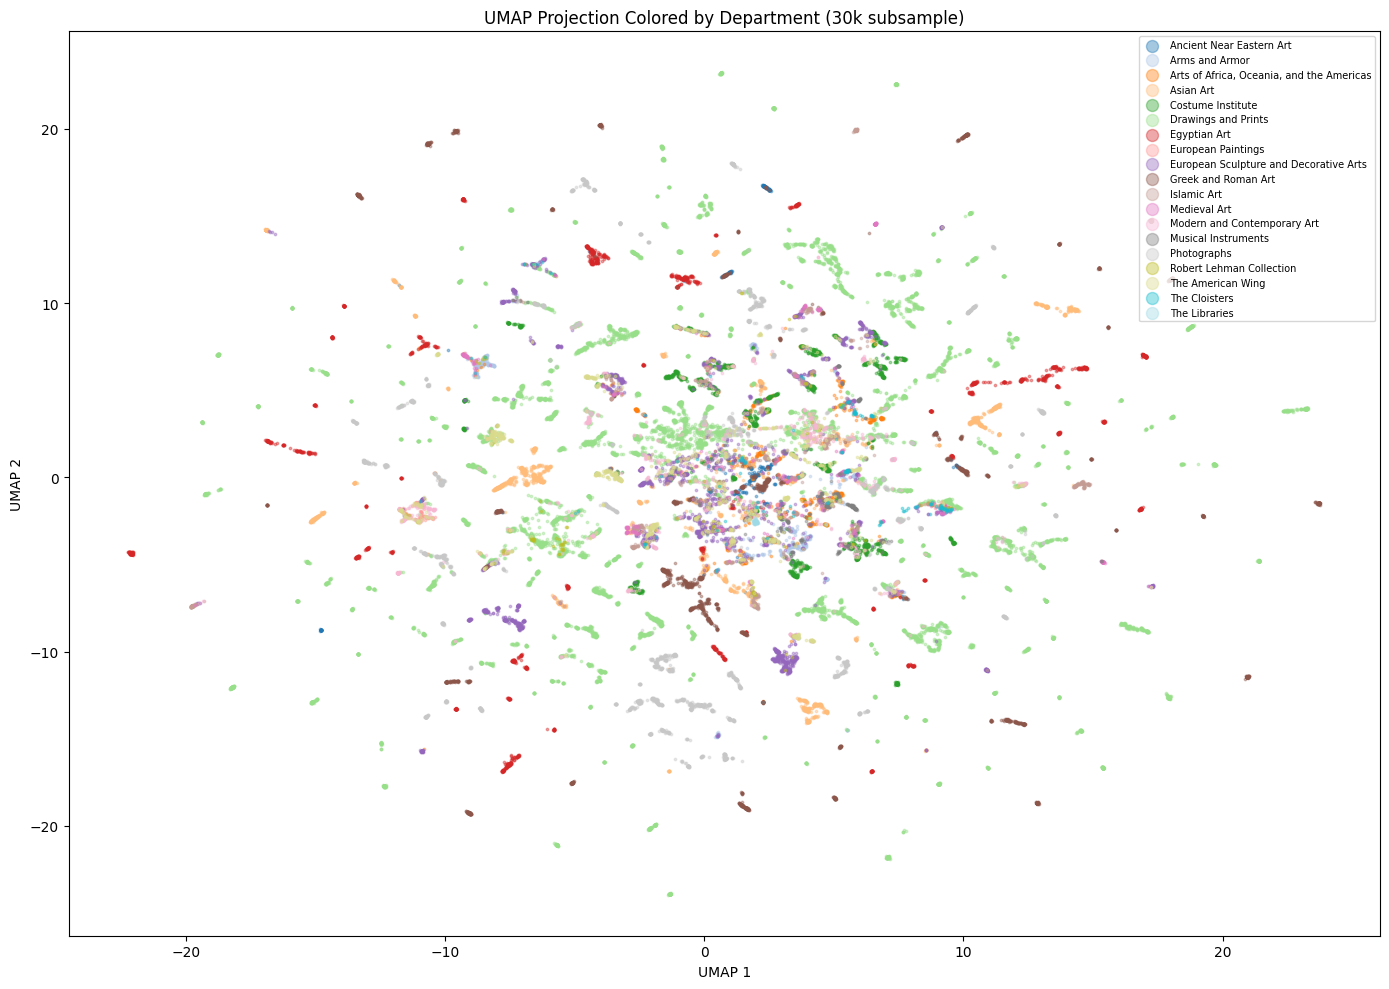

Saved → c:\Users\kauss\cultural-pattern-discovery-ml\outputs\figures\umap_by_department.png


In [18]:
# Map integer labels back to department names for the legend
dept_names = le.inverse_transform(y_umap_sample)

fig, ax = plt.subplots(figsize=(14, 10))

# 19 departments need a colormap with enough distinct colors
cmap = plt.cm.get_cmap('tab20', len(le.classes_))

for i, dept in enumerate(le.classes_):
    mask = dept_names == dept
    ax.scatter(
        X_umap_2d[mask, 0], X_umap_2d[mask, 1],
        s=3, alpha=0.4, label=dept, color=cmap(i)
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP Projection Colored by Department (30k subsample)')
ax.legend(markerscale=5, fontsize=7, loc='upper right', ncol=1, framealpha=0.8)

plt.tight_layout()
out_path = os.path.join(FIGURES, 'umap_by_department.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

### Phase 2 - Summary

The UMAP projection shows partial structure — some departments form distinct islands at the edges (Egyptian Art, Photographs), but the center is heavily mixed. Drawings & Prints, the largest department at 35% of the data, is scattered throughout since it covers a wide range of media and time periods. Departments with similar metadata profiles (Medieval Art, The Cloisters, European Sculpture) overlap significantly. This sets realistic expectations: clustering will recover some departmental groupings cleanly but will merge others that are indistinguishable in metadata space.

## Phase 3 — K-Means Clustering

We run K-Means on the SVD-reduced training data for a range of k values. To choose the right k, we use two criteria together: the elbow plot (inertia vs k) and the silhouette score.

### Elbow Plot and Silhouette Analysis

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test a range of k values around the known 19 departments.
# MiniBatchKMeans would be faster, but standard KMeans is more accurate
# and manageable at 388k × 50.

K_RANGE = range(5, 31)
inertias = []
silhouette_scores = []

for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_reduced)
    inertias.append(kmeans.inertia_)

    # Silhouette on full 388k is slow — compute on a subsample
    sil_sample_idx = np.random.RandomState(42).choice(len(X_train_reduced), 20_000, replace=False)
    sil = silhouette_score(X_train_reduced[sil_sample_idx], labels[sil_sample_idx])
    silhouette_scores.append(sil)

    print(f"k={k:>2}  inertia={kmeans.inertia_:,.0f}  silhouette={sil:.4f}")

k= 5  inertia=39,449,319  silhouette=0.1228
k= 6  inertia=38,260,203  silhouette=0.2436
k= 7  inertia=37,085,869  silhouette=0.1569
k= 8  inertia=35,732,690  silhouette=0.1578
k= 9  inertia=34,275,735  silhouette=0.1412
k=10  inertia=32,696,872  silhouette=0.1864
k=11  inertia=31,547,826  silhouette=0.1518
k=12  inertia=30,531,246  silhouette=0.1578
k=13  inertia=29,742,860  silhouette=0.1659
k=14  inertia=28,954,007  silhouette=0.1678
k=15  inertia=27,985,373  silhouette=0.1730
k=16  inertia=26,870,048  silhouette=0.1766
k=17  inertia=25,850,061  silhouette=0.1810
k=18  inertia=25,086,103  silhouette=0.1869
k=19  inertia=24,203,442  silhouette=0.1972
k=20  inertia=23,480,269  silhouette=0.1821
k=21  inertia=22,649,325  silhouette=0.1919
k=22  inertia=21,871,001  silhouette=0.1963
k=23  inertia=21,152,605  silhouette=0.2019
k=24  inertia=20,220,889  silhouette=0.2183
k=25  inertia=19,666,352  silhouette=0.2360
k=26  inertia=19,396,284  silhouette=0.2013
k=27  inertia=18,447,651  silhou

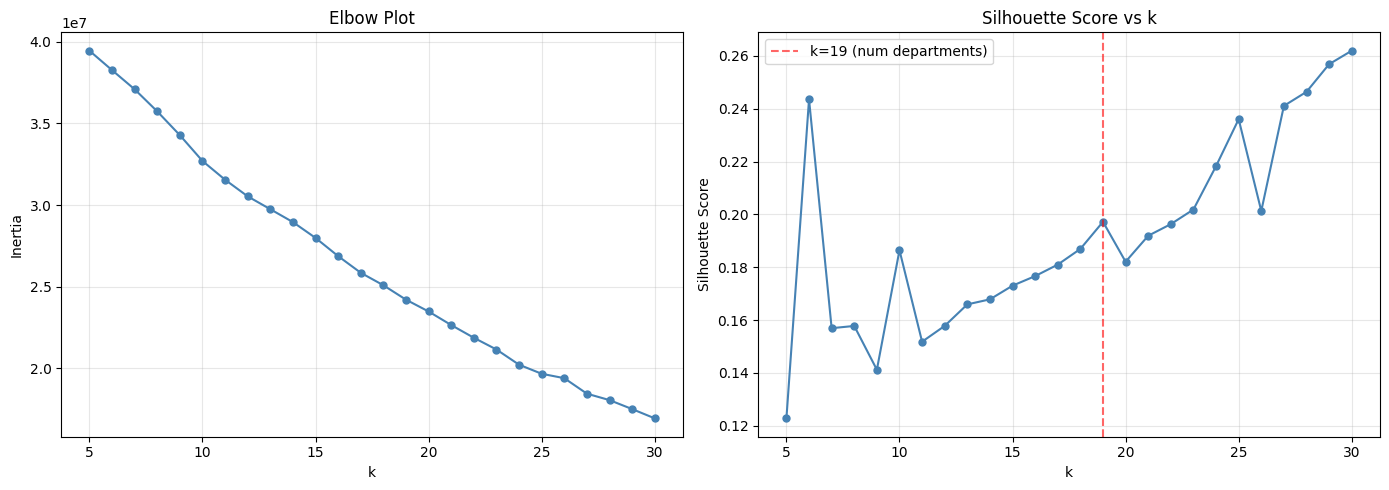

Saved → c:\Users\kauss\cultural-pattern-discovery-ml\outputs\figures\kmeans_elbow_silhouette.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(K_RANGE), inertias, marker='o', markersize=5, color='steelblue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Plot')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(list(K_RANGE), silhouette_scores, marker='o', markersize=5, color='steelblue')
axes[1].axvline(x=19, color='red', linestyle='--', alpha=0.6, label='k=19 (num departments)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_path = os.path.join(FIGURES, 'kmeans_elbow_silhouette.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

**Observations:** There's no clear elbow in the inertia curve, confirming the UMAP finding that the data lacks crisp cluster boundaries. The silhouette plot shows a spike at k=6, suggesting roughly 6 broad natural groupings, and a gradual rise from k=19 onward. We proceed with four values:
- **k=6** — local silhouette peak, tests whether the algorithm discovers broader macro-groupings on its own
- **k=19** — matches the number of departments, lets us directly compare cluster assignments against curatorial labels
- **k=25** — silhouette continues climbing in this range
- **k=30** — highest silhouette in our tested range, tests whether finer granularity produces better-separated clusters

### Fit K-Means for Selected k Values


In [21]:
# Fit K-Means for each selected k and store results
K_VALUES = [6, 19, 25, 30]
kmeans_models = {}
cluster_labels = {}

for k in K_VALUES:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_reduced)
    kmeans_models[k] = km
    cluster_labels[k] = labels

    print(f"\n── k={k} ──")
    unique, counts = np.unique(labels, return_counts=True)
    for cluster_id, count in zip(unique, counts):
        print(f"  Cluster {cluster_id:>2}: {count:>6,} ({count/len(labels)*100:.1f}%)")


── k=6 ──
  Cluster  0:  9,701 (2.5%)
  Cluster  1: 34,958 (9.0%)
  Cluster  2: 282,252 (72.8%)
  Cluster  3:  1,617 (0.4%)
  Cluster  4: 53,920 (13.9%)
  Cluster  5:  5,516 (1.4%)

── k=19 ──
  Cluster  0:  6,024 (1.6%)
  Cluster  1:  8,288 (2.1%)
  Cluster  2:  7,392 (1.9%)
  Cluster  3: 115,762 (29.8%)
  Cluster  4: 128,252 (33.1%)
  Cluster  5:  8,712 (2.2%)
  Cluster  6:  5,515 (1.4%)
  Cluster  7:  1,841 (0.5%)
  Cluster  8: 17,604 (4.5%)
  Cluster  9: 24,494 (6.3%)
  Cluster 10:  3,347 (0.9%)
  Cluster 11: 28,918 (7.5%)
  Cluster 12:  4,780 (1.2%)
  Cluster 13:  1,330 (0.3%)
  Cluster 14:  3,673 (0.9%)
  Cluster 15:  7,736 (2.0%)
  Cluster 16:  4,938 (1.3%)
  Cluster 17:  1,543 (0.4%)
  Cluster 18:  7,815 (2.0%)

── k=25 ──
  Cluster  0:  4,172 (1.1%)
  Cluster  1: 10,477 (2.7%)
  Cluster  2: 24,223 (6.2%)
  Cluster  3: 110,425 (28.5%)
  Cluster  4:  1,841 (0.5%)
  Cluster  5:  4,912 (1.3%)
  Cluster  6:  7,735 (2.0%)
  Cluster  7:  8,288 (2.1%)
  Cluster  8:  8,882 (2.3%)
  Cl

### Visualize K-Means Clusters on UMAP

C:\Users\kauss\AppData\Local\Temp\ipykernel_70452\2878391266.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', k)
C:\Users\kauss\AppData\Local\Temp\ipykernel_70452\2878391266.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', k)
C:\Users\kauss\AppData\Local\Temp\ipykernel_70452\2878391266.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', k)
C:\Users\kauss\AppData

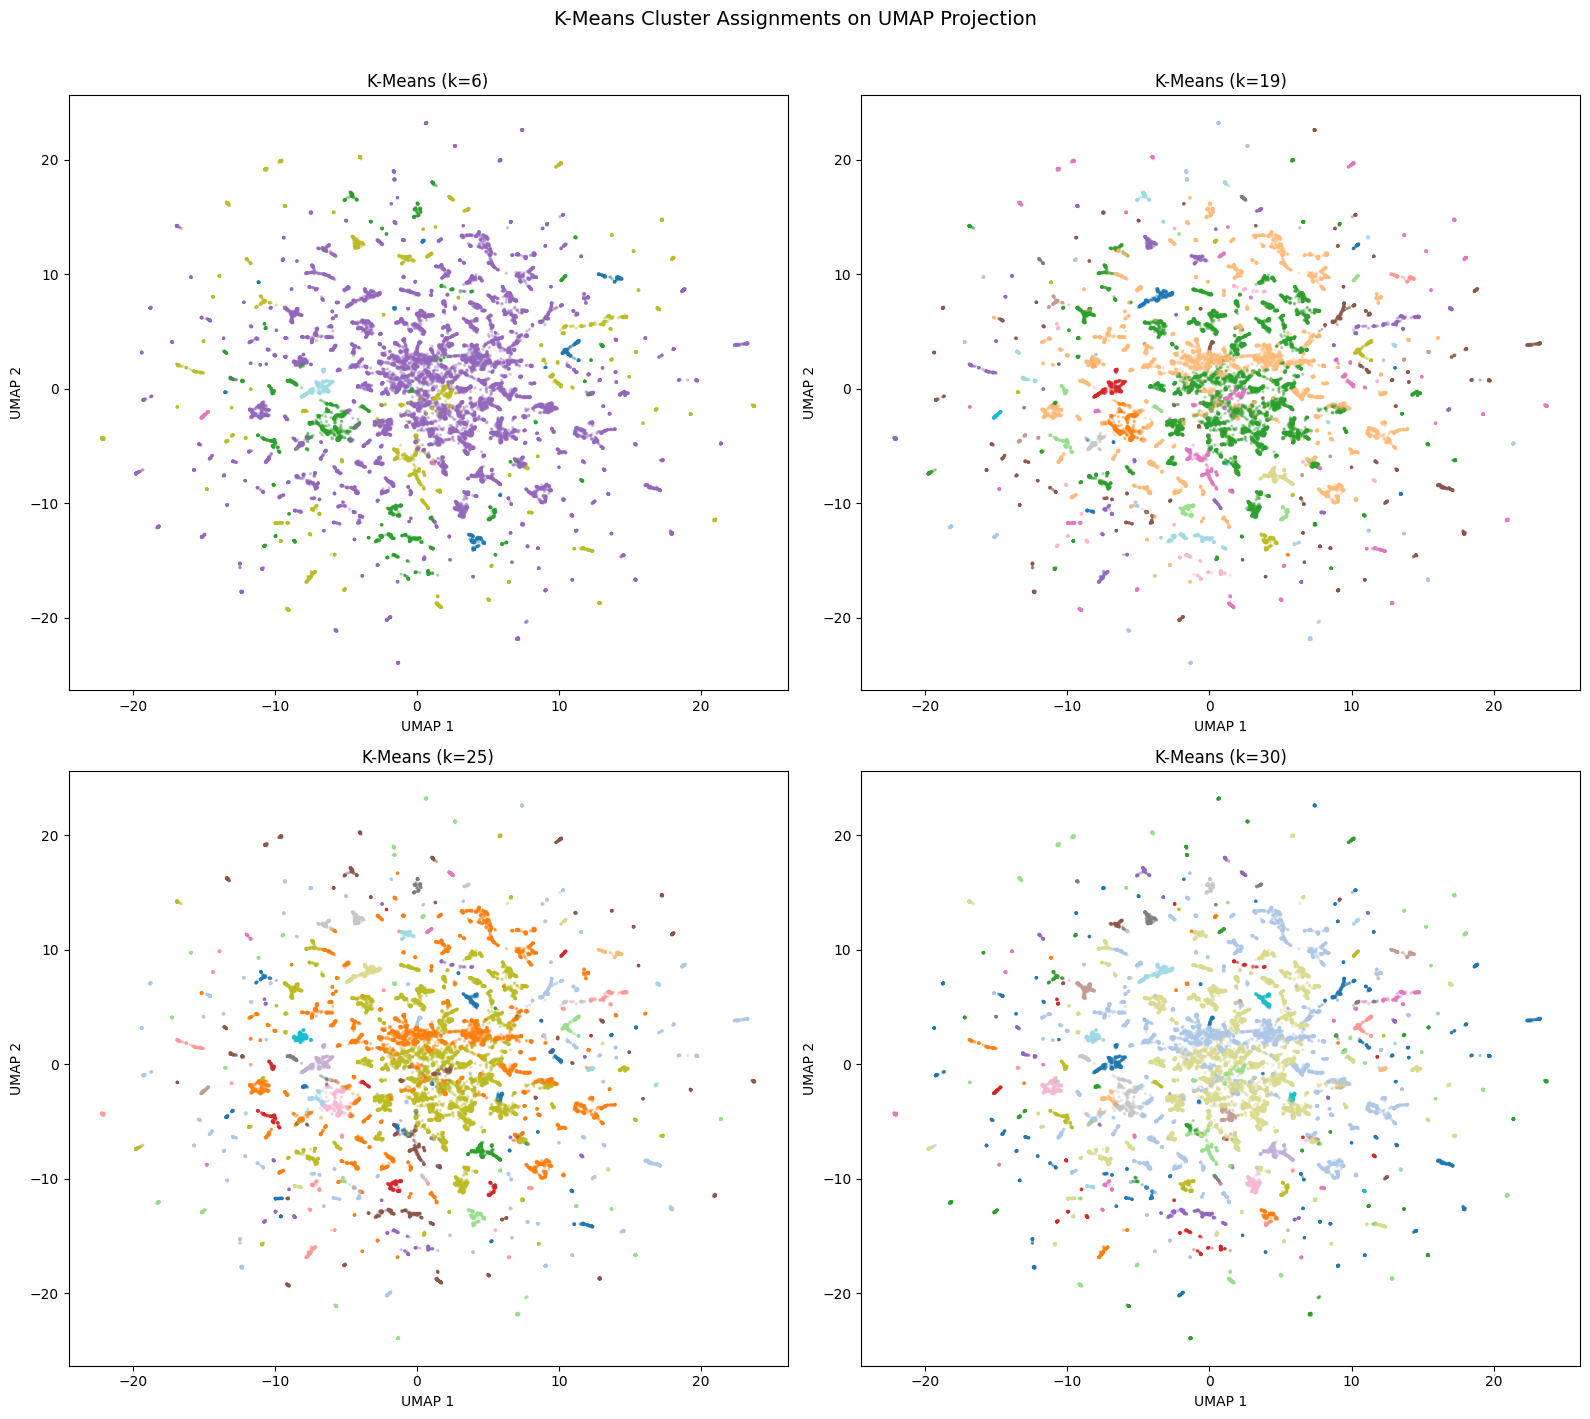

Saved → c:\Users\kauss\cultural-pattern-discovery-ml\outputs\figures\kmeans_clusters_umap.png


In [22]:
# Get cluster labels for the UMAP subsample by predicting from the fitted models
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, k in zip(axes.flat, K_VALUES):
    # Predict cluster assignments for the UMAP subsample
    sub_labels = kmeans_models[k].predict(X_umap_sample)
    
    cmap = plt.cm.get_cmap('tab20', k)
    scatter = ax.scatter(
        X_umap_2d[:, 0], X_umap_2d[:, 1],
        c=sub_labels, cmap=cmap, s=2, alpha=0.3
    )
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f'K-Means (k={k})')

plt.suptitle('K-Means Cluster Assignments on UMAP Projection', fontsize=14, y=1.01)
plt.tight_layout()
out_path = os.path.join(FIGURES, 'kmeans_clusters_umap.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

### Observations from K-Means Cluster Assignments on UMAP Projection

The UMAP projections colored by K-Means cluster assignments (k = 6, 19, 25, 30) reveal consistent structural patterns across all values of k. Most notably, there is a dense central region where points from different clusters heavily overlap, indicating the absence of clear global separability in the data. Even as k increases, this central “core” persists and is merely partitioned into smaller segments rather than being cleanly separated into distinct clusters.

At lower k (e.g., k = 6), the algorithm collapses most data into one dominant cluster, obscuring any finer structure. As k increases (k = 19, 25, 30), more clusters appear, but these primarily reflect fragmentation of the same overlapping region rather than the emergence of new, well-defined groupings. This is consistent with earlier findings from the elbow plot and silhouette scores, which showed no clear optimal number of clusters.

In contrast, smaller peripheral regions—visible as isolated “islands” in the UMAP space—are more stable and become increasingly well-defined as k increases. These likely correspond to more distinct subsets of the data (e.g., specific materials or historical periods), and align with earlier observations of pure clusters in the cluster–department heatmaps.

Overall, the visualization suggests that the dataset exhibits strong local structure but weak global structure. While certain subsets are clearly separable, the majority of the data lies in a highly overlapping region, indicating that clustering algorithms like K-Means are partitioning a continuous space rather than uncovering naturally distinct groups. This further supports the conclusion that curator-defined departments only partially align with the intrinsic structure of the data.

### Evaluate Clusters Against Department Labels

Two metrics to quantify how well clusters align with departments:
- **Adjusted Rand Index (ARI)** — measures overlap between cluster assignments and department labels, adjusted for chance. 0 means random, 1 means perfect agreement.
- **Normalized Mutual Information (NMI)** — measures how much knowing the cluster tells you about the department. 0 means nothing, 1 means full information.

In [23]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print(f"{'k':>3}  {'ARI':>8}  {'NMI':>8}")
print(f"{'---':>3}  {'--------':>8}  {'--------':>8}")

for k in K_VALUES:
    ari = adjusted_rand_score(y_train, cluster_labels[k])
    nmi = normalized_mutual_info_score(y_train, cluster_labels[k])
    print(f"{k:>3}  {ari:>8.4f}  {nmi:>8.4f}")

  k       ARI       NMI
---  --------  --------
  6    0.1689    0.3797
 19    0.2797    0.5309
 25    0.2484    0.5108
 30    0.2603    0.5026


### Cluster vs Department Cross-Tabulation (k=19)

The scores above are summaries. The cross-tab shows the full picture: for each cluster, which departments ended up there? Pure clusters mean the algorithm found a real boundary. Mixed clusters mean those departments are indistinguishable in metadata space.

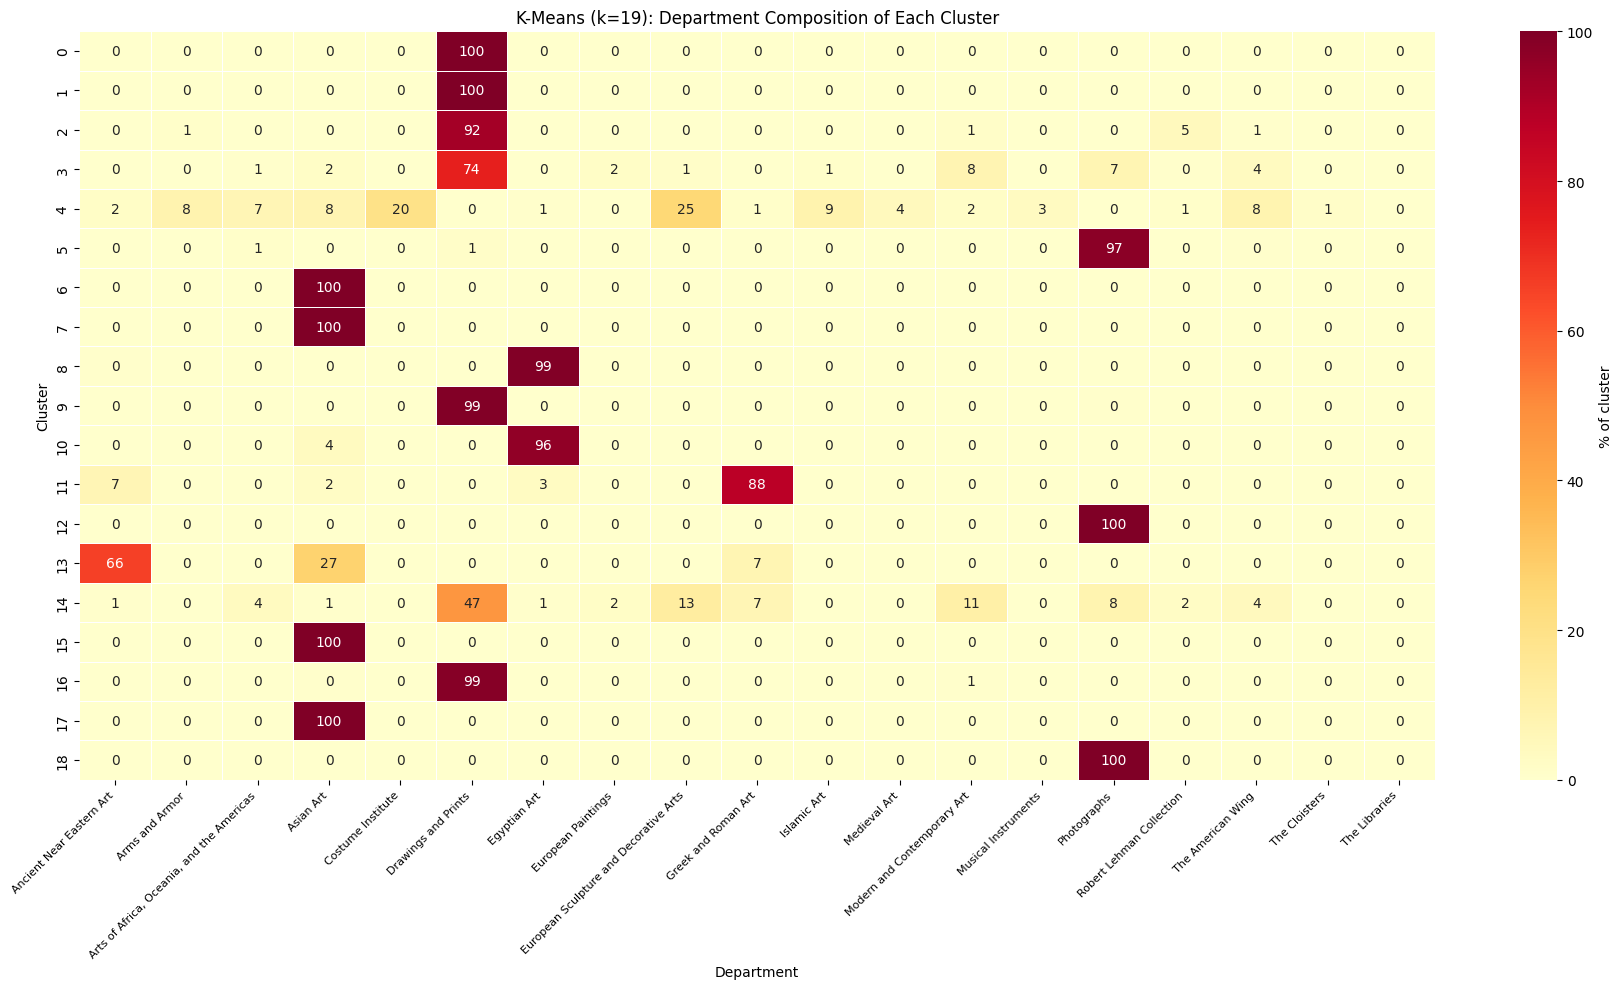

Saved → c:\Users\kauss\cultural-pattern-discovery-ml\outputs\figures\kmeans_19_crosstab_heatmap.png


In [26]:
# Build a cross-tabulation: rows = clusters, columns = departments
dept_names_train = le.inverse_transform(y_train)

crosstab = pd.crosstab(
    cluster_labels[19],
    dept_names_train,
    margins=False
)

# Normalize each row to percentages (what % of each cluster comes from each department)
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

# Plot as heatmap
fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(
    crosstab_pct,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': '% of cluster'},
    ax=ax
)
ax.set_xlabel('Department')
ax.set_ylabel('Cluster')
ax.set_title('K-Means (k=19): Department Composition of Each Cluster')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()

out_path = os.path.join(FIGURES, 'kmeans_19_crosstab_heatmap.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

**Observations (k=19):** Several clusters are nearly pure — the algorithm cleanly isolates Asian Art (Clusters 6, 7, 15, 17), Photographs (Clusters 6, 12, 18), and Egyptian Art (Cluster 8). However, Drawings & Prints gets split across at least 4 clusters (0, 1, 2, 3) — the algorithm sees sub-groups within it rather than treating it as one department. The messiest clusters are 4 (European Sculpture + Costume Institute + Asian Art + Arms and Armor) and 14 (Drawings & Prints + European Paintings + European Sculpture + Modern Art). Notably absent as clean clusters: Medieval Art, The Cloisters, Robert Lehman Collection, Islamic Art, and The Libraries — all small departments that get absorbed into larger mixed clusters.

### Cluster vs Department Cross-Tabulation (k=6)

The silhouette spike at k=6 suggested 6 broad natural groupings. Does the algorithm discover macro-categories that align with how curators think about the collection?

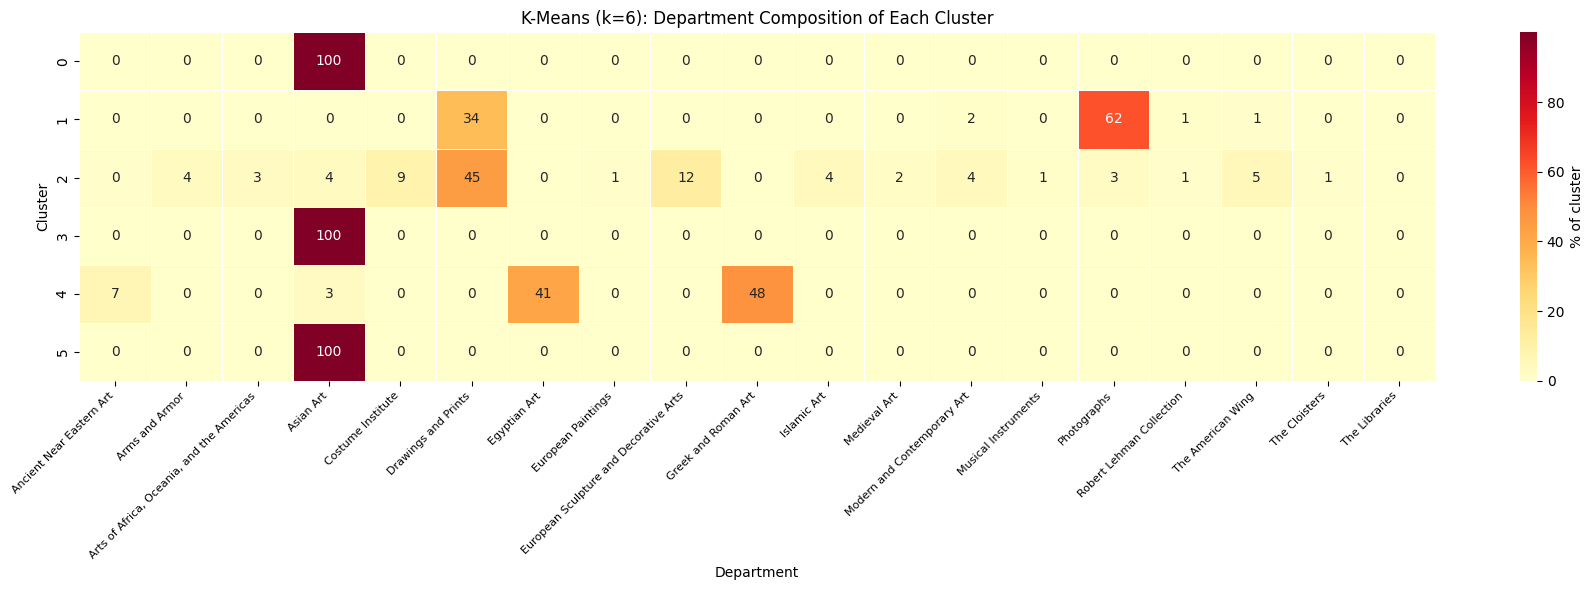

Saved → c:\Users\kauss\cultural-pattern-discovery-ml\outputs\figures\kmeans_6_crosstab_heatmap.png


In [27]:
crosstab_6 = pd.crosstab(
    cluster_labels[6],
    dept_names_train,
    margins=False
)

crosstab_6_pct = crosstab_6.div(crosstab_6.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    crosstab_6_pct,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': '% of cluster'},
    ax=ax
)
ax.set_xlabel('Department')
ax.set_ylabel('Cluster')
ax.set_title('K-Means (k=6): Department Composition of Each Cluster')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()

out_path = os.path.join(FIGURES, 'kmeans_6_crosstab_heatmap.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

**Observations (k=6):** The algorithm discovers an "Ancient World" macro-group (Egyptian + Greek/Roman + Ancient Near Eastern) and splits Asian Art into three sub-clusters, suggesting internal structure within that department. Photographs and Drawings & Prints get grouped together as a media-based cluster. However, the majority of Western departments collapse into one large mixed cluster (Cluster 2, 73% of the data). The supervised classification used a similar 6-group hierarchy (Ancient, Asian, European, American, Modern, Specialized) — the unsupervised approach agrees on the Ancient and Asian groupings but can't separate European, American, and Modern departments from each other without labels.

## Phase 4 — Hierarchical Clustering

Hierarchical (agglomerative) clustering builds a tree of merges from the bottom up — each artwork starts as its own cluster, and the algorithm repeatedly merges the two closest clusters until everything is in one group. The dendrogram shows this merge history, which tells us something K-Means can't: which departments the algorithm considers most similar to each other.

Unlike K-Means, agglomerative clustering requires an n × n distance matrix in memory. Hence, we subsample ~15k rows with stratification to preserve department proportions.

### Stratified Subsample

In [34]:
from sklearn.utils import resample

HIER_SAMPLE_SIZE = 15000

# Stratified subsample to preserve department proportions
X_hier_sample, y_hier_sample = resample(
    X_train_reduced, y_train,
    n_samples=HIER_SAMPLE_SIZE,
    stratify=y_train,
    random_state=42
)

print(f"Subsample shape: {X_hier_sample.shape}")
print(f"Departments represented: {len(np.unique(y_hier_sample))}")

Subsample shape: (15000, 50)
Departments represented: 19


### Dendrogram

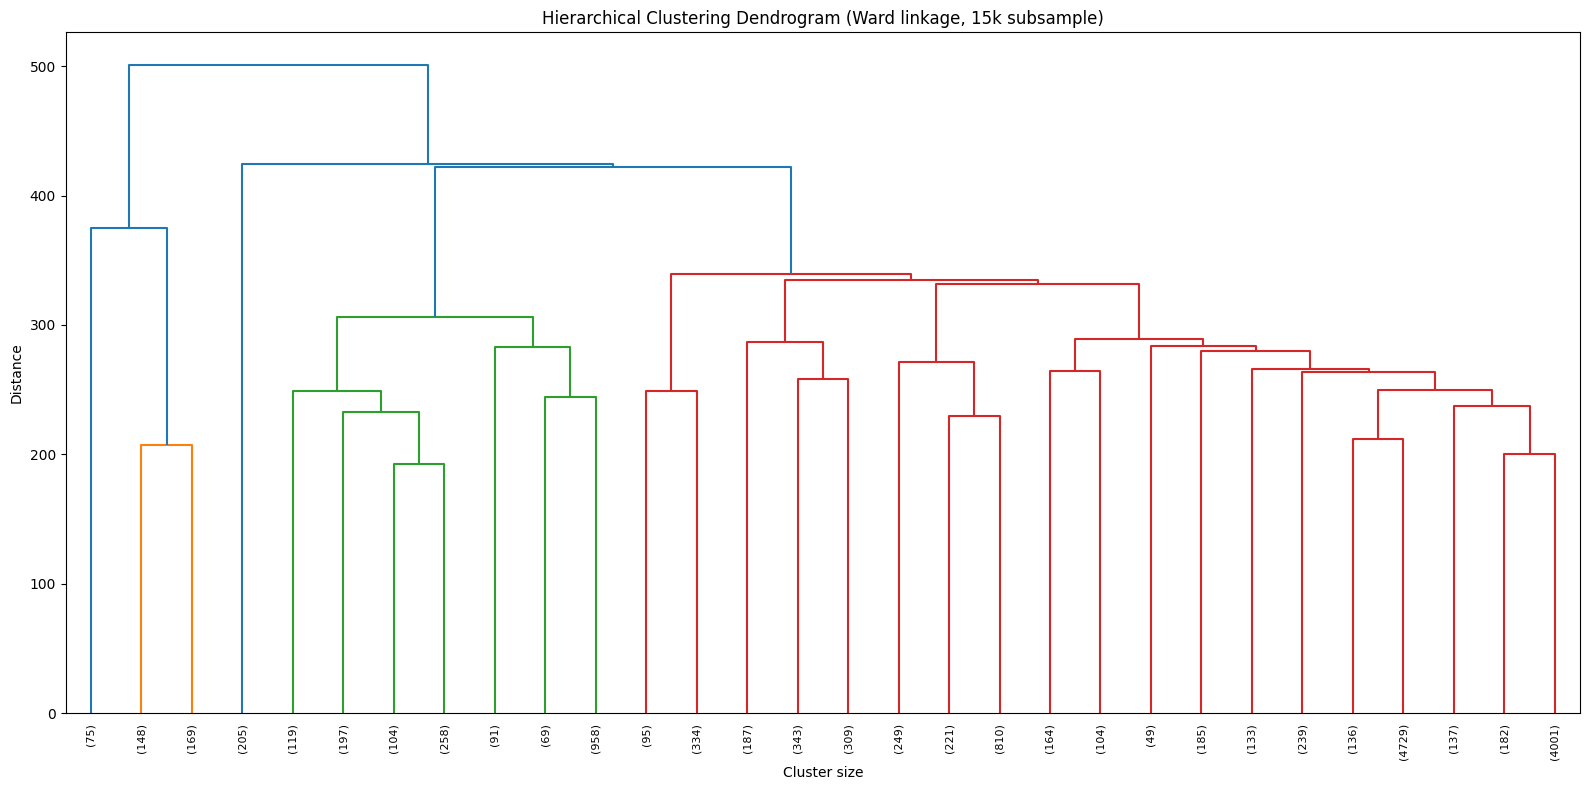

Saved → c:\Users\kauss\cultural-pattern-discovery-ml\outputs\figures\hierarchical_dendrogram.png


In [35]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Ward linkage minimizes the total within-cluster variance at each merge step.
# This tends to produce compact, evenly-sized clusters.
Z = linkage(X_hier_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merges
    p=30,                    # top 30 branches
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax
)
ax.set_xlabel('Cluster size')
ax.set_ylabel('Distance')
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage, 15k subsample)')

plt.tight_layout()
out_path = os.path.join(FIGURES, 'hierarchical_dendrogram.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

**Observations:** The dendrogram shows a clear top-level split (blue branches) separating a small number of groups on the left from a large mass on the right. The right side contains the biggest branches — (4729) and (4001) — which are likely dominated by Drawings & Prints and other large departments. The left-side branches (orange/green) merge at lower distances, meaning those groups are more internally similar and more distinct from the rest of the collection. The merge heights give us useful information: groups that merge at low distance are similar, groups that stay separate until high distance are genuinely different. To see which departments correspond to which branches, we need to cut the tree.

### Cut Dendrogram and Evaluate Against Departments

In [31]:
from scipy.cluster.hierarchy import fcluster

# Cut the tree to produce 19 clusters (matching department count)
hier_labels = fcluster(Z, t=19, criterion='maxclust')

# Evaluate against department labels
ari = adjusted_rand_score(y_hier_sample, hier_labels)
nmi = normalized_mutual_info_score(y_hier_sample, hier_labels)

print(f"Hierarchical clustering (k=19, Ward linkage)")
print(f"  ARI: {ari:.4f}")
print(f"  NMI: {nmi:.4f}")

Hierarchical clustering (k=19, Ward linkage)
  ARI: 0.0424
  NMI: 0.4064


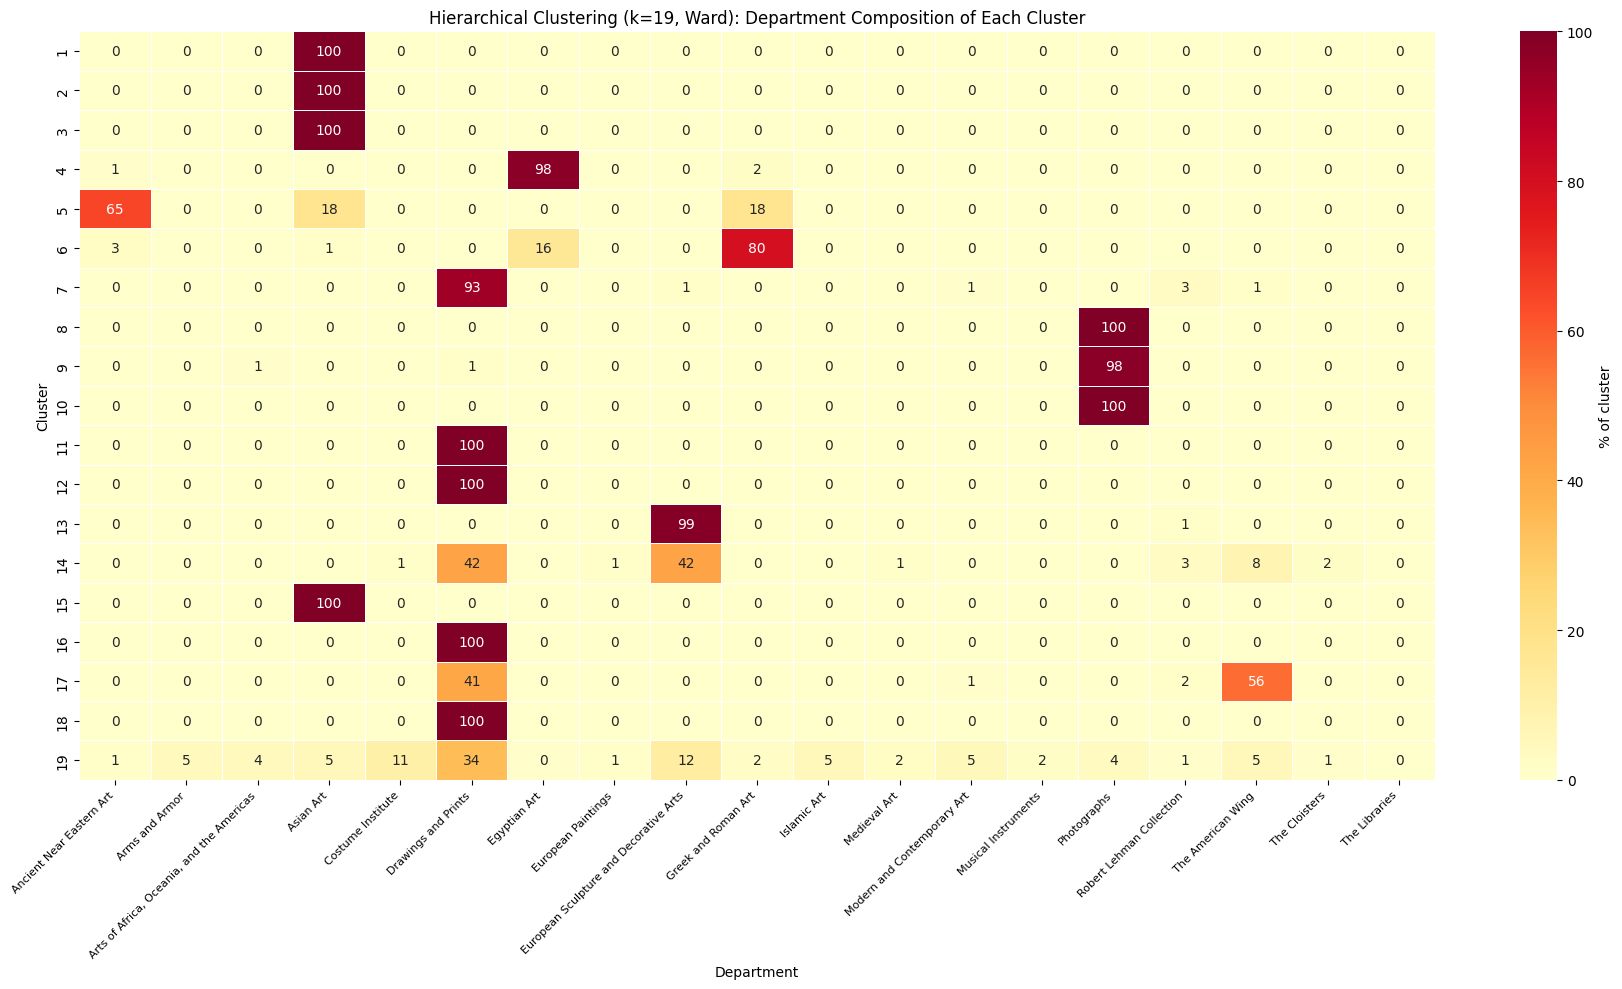

Saved → c:\Users\kauss\cultural-pattern-discovery-ml\outputs\figures\hierarchical_19_crosstab_heatmap.png


In [36]:
# Cross-tab for hierarchical clustering
dept_names_hier = le.inverse_transform(y_hier_sample)

crosstab_hier = pd.crosstab(
    hier_labels,
    dept_names_hier,
    margins=False
)

crosstab_hier_pct = crosstab_hier.div(crosstab_hier.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(
    crosstab_hier_pct,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': '% of cluster'},
    ax=ax
)
ax.set_xlabel('Department')
ax.set_ylabel('Cluster')
ax.set_title('Hierarchical Clustering (k=19, Ward): Department Composition of Each Cluster')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()

out_path = os.path.join(FIGURES, 'hierarchical_19_crosstab_heatmap.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

**Observations:** Some patterns are similar to K-Means — Asian Art gets split into multiple pure clusters (1, 2, 3, 15), Photographs forms its own clean clusters (8, 9, 10), and Drawings & Prints dominates several clusters (7, 11, 12, 16, 18). But there are also differences:
- Cluster 5 merges Ancient Near Eastern Art (65%) with Asian Art (18%) and Greek/Roman (18%) — the algorithm sees ancient civilizations as related, grouping them differently than K-Means did.
- Cluster 6 groups Greek and Roman Art (80%) with Drawings & Prints (16%) — K-Means kept Greek/Roman closer to Egyptian Art instead.
- Cluster 17 merges Drawings & Prints (41%) with The American Wing (56%) — a grouping K-Means didn't produce.
- Cluster 19 is the catch-all — a mix of everything, similar to K-Means' mixed clusters but with even more departments represented.

The lower ARI (0.04 vs 0.28 for K-Means) is driven by these different merge decisions and by the algorithm splitting Drawings & Prints and Asian Art across many clusters. Despite the weaker quantitative scores, the hierarchical approach surfaces different relationships — particularly the Ancient Near Eastern / Asian Art / Greek-Roman connection in Cluster 5, which reflects a geographic and temporal proximity that K-Means missed.

### Hierarchical Clustering Cross-Tab (k=6)

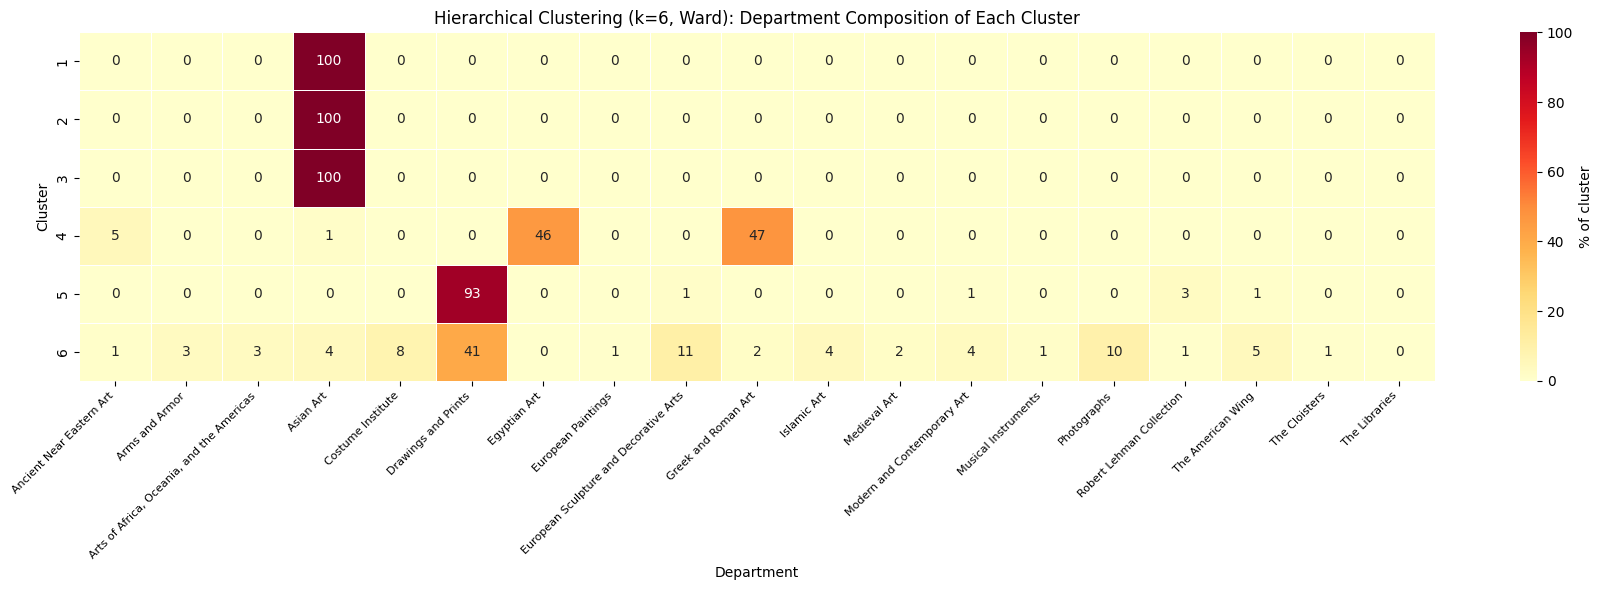

Saved → c:\Users\kauss\cultural-pattern-discovery-ml\outputs\figures\hierarchical_6_crosstab_heatmap.png


In [37]:
hier_labels_6 = fcluster(Z, t=6, criterion='maxclust')

dept_names_hier = le.inverse_transform(y_hier_sample)

crosstab_hier_6 = pd.crosstab(hier_labels_6, dept_names_hier, margins=False)
crosstab_hier_6_pct = crosstab_hier_6.div(crosstab_hier_6.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    crosstab_hier_6_pct,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': '% of cluster'},
    ax=ax
)
ax.set_xlabel('Department')
ax.set_ylabel('Cluster')
ax.set_title('Hierarchical Clustering (k=6, Ward): Department Composition of Each Cluster')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()

out_path = os.path.join(FIGURES, 'hierarchical_6_crosstab_heatmap.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

**Observations (k=6, hierarchical):** Comparing with K-Means k=6:
- Both algorithms split Asian Art into multiple pure clusters (here 1, 2, 3) — confirming that Asian Art has strong internal sub-structure in the metadata.
- Cluster 4 groups Egyptian Art (46%) with Greek and Roman Art (47%) — an "Ancient World" grouping, similar to what K-Means found but without Ancient Near Eastern Art.
- Cluster 5 is 93% Drawings & Prints — K-Means mixed it with Photographs, hierarchical keeps it purer.
- Cluster 6 is the catch-all, but notably has 10% Photographs and 11% European Sculpture — departments that K-Means separated more cleanly.

Both methods agree on the big picture: Asian Art is distinct and separable, the ancient departments group together, and most Western/modern departments collapse into a single mixed cluster. The specific groupings differ at the edges, but the macro-structure is consistent across algorithms — which is a stronger finding than either method alone.

## Phase 5 — Feature Group Ablation

The feature matrix is built from distinct groups: 14 dense features (numeric, boolean, encoded categoricals), 100 Medium TF-IDF, 50 Tags TF-IDF, and 50 Period TF-IDF. Which of these actually drive the clustering? We run K-Means (k=19) separately on each group and on all combined, and compare ARI/NMI scores. If one group alone nearly matches the full-feature score, it's doing most of the work. If a group adds nothing, that's also worth knowing.

### Split Features by Group

In [38]:
# The 214 columns in X_train_scaled are ordered:
# [0:14]    → dense features (booleans, AccessionYear, encoded categoricals, dates, age, span)
# [14:114]  → Medium TF-IDF (100 features)
# [114:164] → Tags TF-IDF (50 features)
# [164:214] → Period TF-IDF (50 features)

feature_groups = {
    'Dense (14)':       X_train_scaled[:, :14],
    'Medium TF-IDF (100)': X_train_scaled[:, 14:114],
    'Tags TF-IDF (50)':    X_train_scaled[:, 114:164],
    'Period TF-IDF (50)':  X_train_scaled[:, 164:214],
    'All features (214)':  X_train_scaled,
}

for name, X in feature_groups.items():
    print(f"{name:25s} shape: {X.shape}")

Dense (14)                shape: (387964, 14)
Medium TF-IDF (100)       shape: (387964, 100)
Tags TF-IDF (50)          shape: (387964, 50)
Period TF-IDF (50)        shape: (387964, 50)
All features (214)        shape: (387964, 214)


### K-Means on Each Feature Group

We run K-Means (k=19) directly on each feature group without SVD reduction. This tests the raw clustering signal in each group independently.

In [39]:
# Run K-Means (k=19) on each feature group and evaluate against department labels
ablation_results = {}

for name, X in feature_groups.items():
    print(f"Running K-Means on {name}...", end=' ')
    km = KMeans(n_clusters=19, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    
    ari = adjusted_rand_score(y_train, labels)
    nmi = normalized_mutual_info_score(y_train, labels)
    ablation_results[name] = {'ARI': ari, 'NMI': nmi}
    print(f"ARI={ari:.4f}  NMI={nmi:.4f}")  

Running K-Means on Dense (14)... ARI=0.2207  NMI=0.4699
Running K-Means on Medium TF-IDF (100)... ARI=-0.0494  NMI=0.2406
Running K-Means on Tags TF-IDF (50)... ARI=-0.0285  NMI=0.0837
Running K-Means on Period TF-IDF (50)... ARI=0.1086  NMI=0.3072
Running K-Means on All features (214)... ARI=0.0293  NMI=0.4078


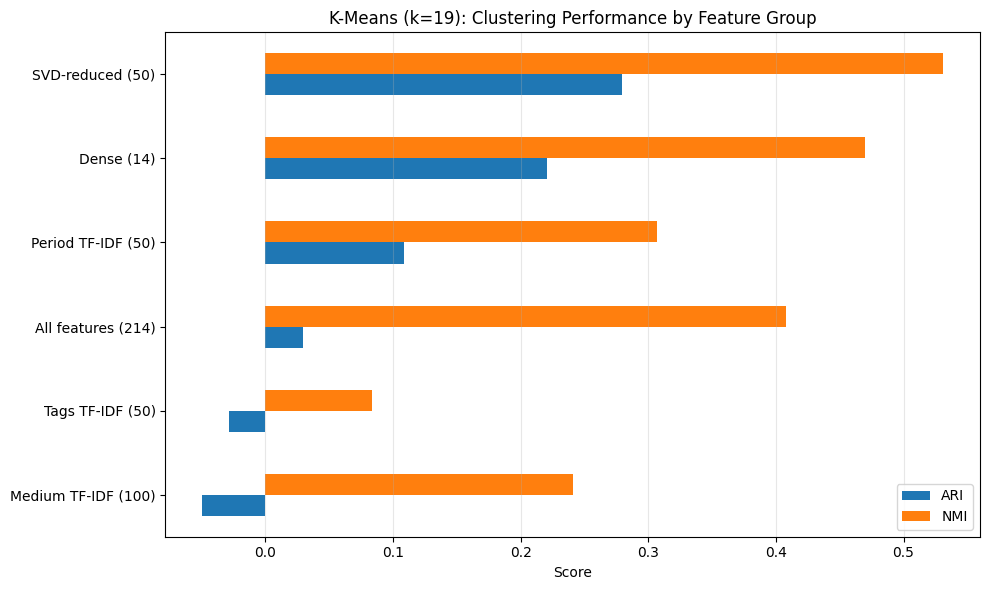

Saved → c:\Users\kauss\cultural-pattern-discovery-ml\outputs\figures\ablation_feature_groups.png


In [40]:
# Add the SVD-reduced result for comparison
ablation_results['SVD-reduced (50)'] = {'ARI': 0.2797, 'NMI': 0.5309}

results_df = pd.DataFrame(ablation_results).T
results_df = results_df.sort_values('ARI', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(kind='barh', ax=ax)
ax.set_xlabel('Score')
ax.set_title('K-Means (k=19): Clustering Performance by Feature Group')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
out_path = os.path.join(FIGURES, 'ablation_feature_groups.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

**Observations:**
- **SVD-reduced (50 components) performs best** — ARI=0.28, NMI=0.53. Dimensionality reduction filters out TF-IDF noise while retaining the useful signal from all feature groups.
- **Dense features alone (14 columns) come close** — ARI=0.22, NMI=0.47. Structured fields like `Is Public Domain`, `object_age`, `Culture`, and `Classification` carry most of the clustering signal. This aligns with the supervised finding that `Is Public Domain` and `Artist Nationality` were the top two SHAP features.
- **All 214 raw features perform poorly** — ARI=0.03. The 200 TF-IDF columns add noise that drowns out the dense feature signal in high-dimensional Euclidean space. This is a direct demonstration of the curse of dimensionality.
- **Medium and Tags TF-IDF have negative ARI** — their clusters are worse than random with respect to departments. These features describe *what objects are made of* and *what they depict*, which cuts across departments rather than aligning with them. Oil on canvas appears in European Paintings, The American Wing, and Modern Art alike.
- **Period TF-IDF is the strongest text group** — ARI=0.11, NMI=0.31. Period labels like "New Kingdom" or "Ming Dynasty" are department-specific, so they carry some clustering signal, though far less than the dense features.

The key takeaway: the Met's departmental structure is primarily encoded in structured metadata (era, provenance, object type) rather than in free-text descriptions of materials or subject tags.

## Phase 6 — Art Historical Periods Analysis

So far we've evaluated clusters against Department labels. But we need to check if clusters align with known art historical periods. The Period column is 81% null, but the ~19% of records that do have period labels contain entries like "New Kingdom", "Ming Dynasty", "Renaissance" — these are the art-historical groupings we want to check.

We load the raw Period strings, take the subset of training records where Period is non-null, and check whether objects from the same historical period tend to land in the same cluster.

In [41]:
# Load the raw CSV to get the original Period strings
df_raw = pd.read_csv('../data/MetObjects.csv', low_memory=False, usecols=['Period'])

# The train/test split used the same random_state=42 and stratify,
# so we can reconstruct the training indices
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    np.arange(len(df_raw)), test_size=0.2, random_state=42,
    stratify=le.fit_transform(pd.read_csv('../data/MetObjects.csv', low_memory=False, usecols=['Department'])['Department'])
)

# Get Period values for training set only
period_train = df_raw.iloc[train_idx]['Period'].reset_index(drop=True)

non_null_mask = period_train.notna()
print(f"Training records with Period: {non_null_mask.sum():,} ({non_null_mask.mean()*100:.1f}%)")
print(f"Unique periods: {period_train[non_null_mask].nunique()}")
print(f"\nTop 15 periods:")
print(period_train[non_null_mask].value_counts().head(15))

Training records with Period: 72,832 (18.8%)
Unique periods: 1687

Top 15 periods:
Period
Edo period (1615–1868)                         7324
Archaic                                        6180
New Kingdom                                    5613
Classical                                      5509
Middle Kingdom                                 3718
Qing dynasty (1644–1911)                       3530
New Kingdom, Ramesside                         2979
Archaic/Classical                              1583
Third Intermediate Period                      1077
Edo (1615–1868) or Meiji period (1868–1912)    1007
Early Imperial                                 1004
Late Period                                     967
Late Archaic                                    921
New Kingdom, Amarna Period                      861
Hellenistic                                     858
Name: count, dtype: int64


### Do Objects from the Same Period Land in the Same Cluster?

We take the top 15 most common periods, find which K-Means (k=19) cluster each object was assigned to, and build a cross-tab. If "New Kingdom" objects all land in the same cluster as "Middle Kingdom" objects, the algorithm is discovering Egyptian art as a coherent group. If "Edo period" and "Qing dynasty" land in separate clusters, it's distinguishing Japanese from Chinese art within Asian Art.

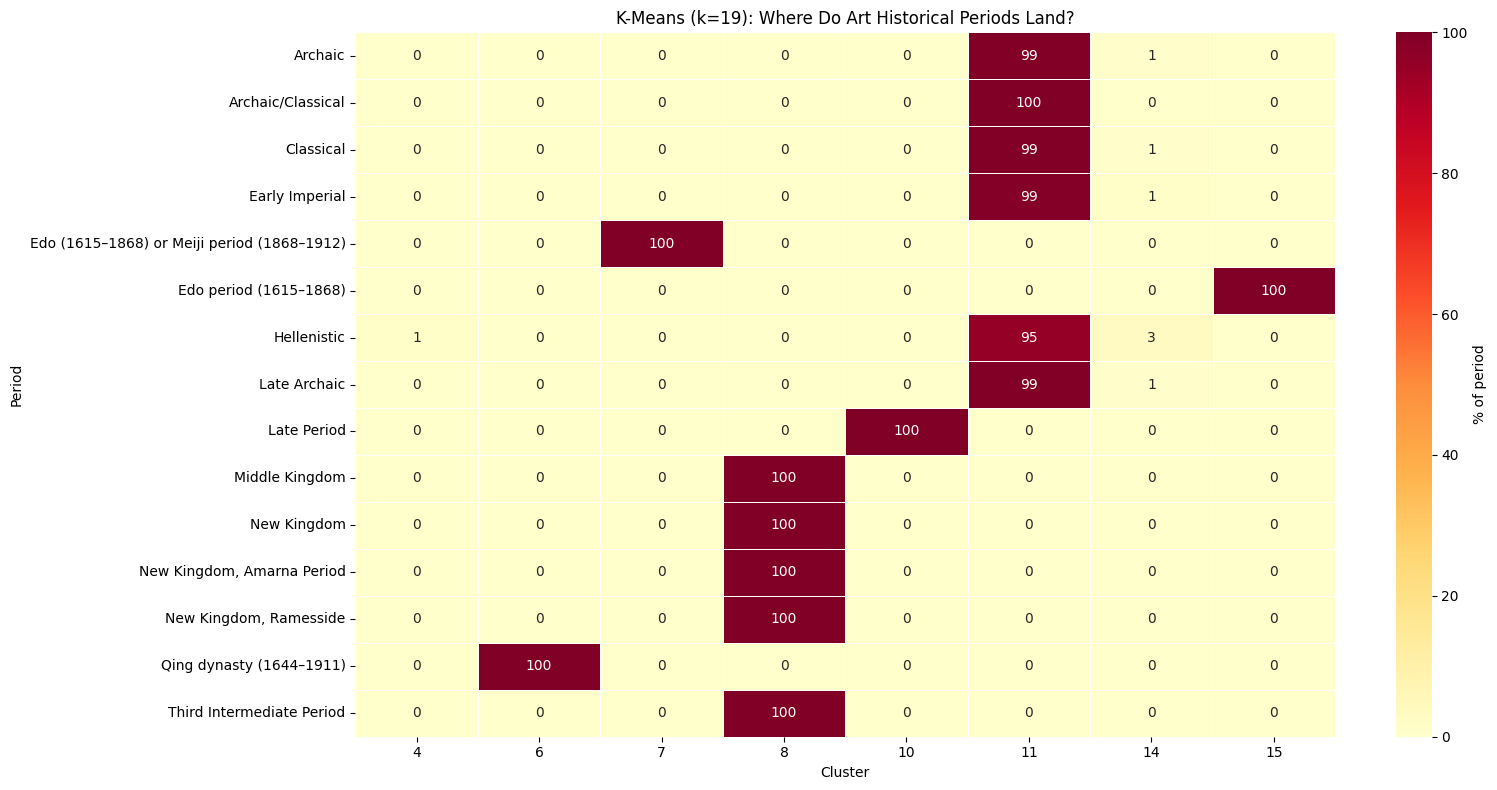

Saved → c:\Users\kauss\cultural-pattern-discovery-ml\outputs\figures\kmeans_19_period_crosstab.png


In [42]:
# Get K-Means (k=19) labels for records with non-null Period
cluster_19_period = cluster_labels[19][non_null_mask]
periods_non_null = period_train[non_null_mask]

# Keep only the top 15 most common periods for a readable heatmap
top_15_periods = periods_non_null.value_counts().head(15).index.tolist()
top_mask = periods_non_null.isin(top_15_periods)

crosstab_period = pd.crosstab(
    periods_non_null[top_mask],
    cluster_19_period[top_mask],
    margins=False
)

# Normalize each row — what % of each period's objects land in each cluster
crosstab_period_pct = crosstab_period.div(crosstab_period.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    crosstab_period_pct,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': '% of period'},
    ax=ax
)
ax.set_xlabel('Cluster')
ax.set_ylabel('Period')
ax.set_title('K-Means (k=19): Where Do Art Historical Periods Land?')
plt.tight_layout()

out_path = os.path.join(FIGURES, 'kmeans_19_period_crosstab.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

**Observations:** This is the clearest result of the analysis. Without ever seeing Period labels, K-Means organizes objects into clusters that map almost perfectly onto art-historical civilizations:
- **Cluster 8 = Egyptian** — New Kingdom, Middle Kingdom, Ramesside, Amarna, Third Intermediate Period, and Late Period all land here at 100%. The algorithm treats all Egyptian periods as one coherent group.
- **Cluster 11 = Greek/Roman** — Archaic, Classical, Hellenistic, Early Imperial, and Late Archaic all land here at 99-100%. The entire classical tradition is unified.
- **Cluster 6 = Chinese** — Qing dynasty at 100%.
- **Cluster 15 = Japanese (Edo)** — at 100%.
- **Cluster 7 = Japanese (transitional)** — Edo/Meiji overlap at 100%.

The algorithm doesn't distinguish between sub-periods within a civilization (New Kingdom vs Middle Kingdom both go to Cluster 8), but it cleanly separates civilizations from each other. This confirms that the Met's metadata carries strong art-historical signal — the departmental structure curators built is genuinely reflected in the structured features, at least at the civilization level.

## Phase 7 - Test Set Validation

Everything so far was on the training set. To check whether the patterns generalize, we assign test set artworks to the nearest K-Means cluster center (learned from training data) and see if the cluster-department alignment holds. If test artworks from Egyptian Art still land in the same cluster as training artworks from Egyptian Art, the structure is real and not an artifact of overfitting to the training data.

In [43]:
# Predict cluster labels for the test set using the K-Means model trained on training data
test_clusters_19 = kmeans_models[19].predict(X_test_reduced)

# Evaluate against department labels
ari_test = adjusted_rand_score(y_test, test_clusters_19)
nmi_test = normalized_mutual_info_score(y_test, test_clusters_19)

print(f"K-Means (k=19) — Train vs Test comparison:")
print(f"  {'':15s} {'ARI':>8}  {'NMI':>8}")
print(f"  {'Train':15s} {0.2797:>8.4f}  {0.5309:>8.4f}")
print(f"  {'Test':15s} {ari_test:>8.4f}  {nmi_test:>8.4f}")

K-Means (k=19) — Train vs Test comparison:
                       ARI       NMI
  Train             0.2797    0.5309
  Test              0.2777    0.5319


### Test Set Cross-Tabulation

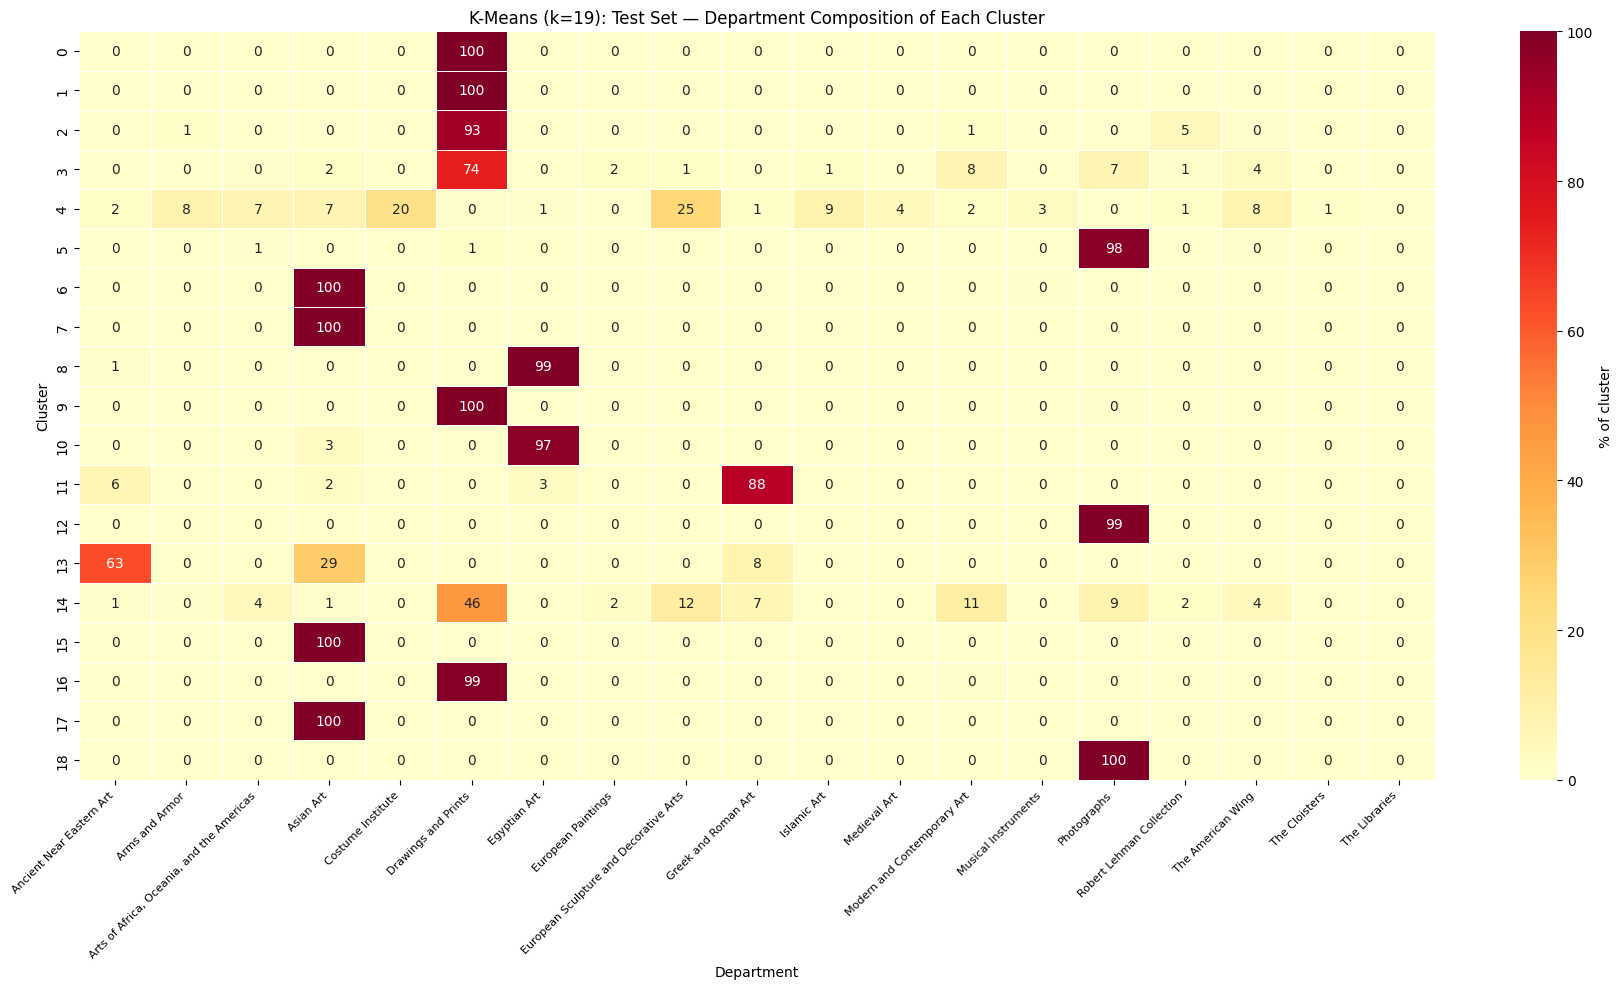

Saved → c:\Users\kauss\cultural-pattern-discovery-ml\outputs\figures\kmeans_19_test_crosstab_heatmap.png


In [44]:
dept_names_test = le.inverse_transform(y_test)

crosstab_test = pd.crosstab(test_clusters_19, dept_names_test, margins=False)
crosstab_test_pct = crosstab_test.div(crosstab_test.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(
    crosstab_test_pct,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': '% of cluster'},
    ax=ax
)
ax.set_xlabel('Department')
ax.set_ylabel('Cluster')
ax.set_title('K-Means (k=19): Test Set — Department Composition of Each Cluster')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()

out_path = os.path.join(FIGURES, 'kmeans_19_test_crosstab_heatmap.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

**Observations:** The test set cluster composition is virtually identical to the training set. The same clusters are pure (Clusters 0, 1, 6, 7, 15, 17 for Drawings & Prints and Asian Art; Cluster 8 for Egyptian Art; Clusters 5, 12, 18 for Photographs). The same clusters are mixed (Cluster 4 remains the European/everything catch-all; Cluster 14 is the same blend of Drawings & Prints, European departments, and Modern Art). ARI and NMI scores differ by less than 0.01 between train and test. The clustering structure is stable and generalizable — it reflects genuine patterns in the metadata, not noise specific to the training sample.